# Scratch 1 — Per-HX Feature Engineering Verification

ทดสอบว่า:
- ตัว parser ดึง `cold_flow / cold_in / cold_out / hot_flow / hot_in / hot_out`
  ออกจาก `HX_CONFIG` ได้ถูกทุกตัว
- มี tag ไหนใน config ที่ไม่อยู่ใน CSV หรือไม่
- คำนวณ `dT_cold / dT_hot / eps (effectiveness) / duty (kW)` ออกมาได้ค่าที่
  สมเหตุสมผล (eps ส่วนใหญ่ควรอยู่ระหว่าง 0–1)
- มี TAM gap กี่ช่องในข้อมูลที่ cleaning notebook ทิ้งไว้

## Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.getcwd())   # so `from hx_config import HX_CONFIG` works
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hx_config import HX_CONFIG
print(f'{len(HX_CONFIG)} heat exchangers configured')

16 heat exchangers configured


In [2]:
df = pd.read_csv(r'C:\Desktop\Bangchak Internship 2026\Data\Process_information_cleaned.csv',
                 index_col='Timestamp', parse_dates=True)
print('data shape:', df.shape)
print('date range:', df.index.min().date(), '->', df.index.max().date())
df.head(3)

data shape: (836, 96)
date range: 2024-01-01 -> 2026-06-02


,00FIC001.pv,00FC501.pv,1AI001.pv,1FC020.pv,1FC021.pv,1FC022.pv,1FC023.pv,1FC035.pv,1FC062.pv,1FI007.pv,...,1TI195.pv,1TI204.pv,1TI211.pv,1TI212.pv,1TI213.pv,1TI225.pv,439FI003.pv,4TI107.pv,4TI115.pv,1fi005.pv
Timestamp,,,,,,,,,,,,,,,,,,,,,
2024-01-01,94.375190,16.999795,1.368275,124.089211,125.962866,125.978625,124.802684,152.314679,0.0,171.321152,...,218.566940,546.100331,151.058213,206.914077,225.330899,85.847724,160.887027,173.001795,185.483304,528.391371
2024-01-02,92.374818,19.953469,1.399654,125.061664,125.352829,125.308419,125.214303,153.472408,0.0,171.194656,...,221.105864,550.839677,151.924575,208.019745,227.095269,85.580113,165.443664,175.752658,187.760991,530.633258
2024-01-03,97.185508,19.541941,1.351021,125.017004,125.024044,124.964214,124.989005,153.883117,0.0,171.241570,...,222.529668,556.754072,152.279872,213.841493,231.224201,86.101482,167.004084,176.971240,189.410400,531.206542


In [3]:
CP_CRUDE = 2.2     # kJ/kg-K   (Equations_Reference doc, assumed crude property)
RHO_CRUDE = 850    # kg/m3     (assumed crude property)

## 1. Tag classification per HX

In [4]:
def classify_side(items):
    flow = t_in = t_out = None
    unclassified = []
    for tag, label, unit in items:
        ll = label.lower()
        if unit == 'M3/HR':
            flow = tag
        elif unit == 'DEGC':
            if 'inlet' in ll:
                t_in = tag
            elif 'outlet' in ll:
                t_out = tag
            else:
                unclassified.append(tag)
    # fallback: e.g. E113A hot side has 'Residue from Distillation' with no
    # explicit inlet/outlet wording -- treat the lone unclassified temp as inlet
    if t_in is None and unclassified:
        t_in = unclassified[0]
    return flow, t_in, t_out

def parse_hx(cfg):
    cold_flow, cold_in, cold_out = classify_side(cfg['cold'])
    hot_flow,  hot_in,  hot_out  = classify_side(cfg['hot'])
    return dict(cold_flow=cold_flow, cold_in=cold_in, cold_out=cold_out,
                hot_flow=hot_flow,   hot_in=hot_in,   hot_out=hot_out)

streams = {hx: parse_hx(cfg) for hx, cfg in HX_CONFIG.items()}
pd.DataFrame(streams).T

,cold_flow,cold_in,cold_out,hot_flow,hot_in,hot_out
E101AB,1FI007.pv,1TI102.pv,1TI101.pv,1FI010.pv,1TI194.pv,1TI103.pv
E101CD,1FI008.pv,1TI102.pv,1TI104.pv,1FI011.pv,1TI194.pv,1TI105.pv
E101EF,1FI009.pv,1TI102.pv,1TI109.pv,1FI012.pv,1TI194.pv,1TI110.pv
E102,None,1TI107.pv,1TI106.pv,1FC055.pv,1TI165.pv,1TI108.pv
E103AB,1FI015.pv,1TI225.pv,1TI136.pv,1FI018.pv,4TI107.pv,1TI137.pv
E104,1FI015.pv,1TI136.pv,1TI112.pv,None,1TI195.pv,4TI115.pv
E105AB,1FI015.pv,1TI112.pv,1TI114.pv,1FC035.pv,1TI195.pv,1TI113.pv
E106AB,1FI016.pv,1TI225.pv,1TI128.pv,1FI019.pv,4TI107.pv,1TI129.pv
E107AB,1FI016.pv,1TI128.pv,1TI130.pv,None,1TI135.pv,1TI131.pv
E108AB,1FI016.pv,1TI130.pv,1TI132.pv,439FI003.pv,1TI127.pv,1TI133.pv


### Check: every classified tag actually exists in the CSV

In [5]:
report = []
for hx, s in streams.items():
    missing = [k for k, v in s.items() if v is not None and v not in df.columns]
    report.append({'HX': hx, **s, 'missing_in_csv': ', '.join(missing) if missing else ''})
pd.DataFrame(report)

,HX,cold_flow,cold_in,cold_out,hot_flow,hot_in,hot_out,missing_in_csv
0,E101AB,1FI007.pv,1TI102.pv,1TI101.pv,1FI010.pv,1TI194.pv,1TI103.pv,
1,E101CD,1FI008.pv,1TI102.pv,1TI104.pv,1FI011.pv,1TI194.pv,1TI105.pv,
2,E101EF,1FI009.pv,1TI102.pv,1TI109.pv,1FI012.pv,1TI194.pv,1TI110.pv,
3,E102,None,1TI107.pv,1TI106.pv,1FC055.pv,1TI165.pv,1TI108.pv,
4,E103AB,1FI015.pv,1TI225.pv,1TI136.pv,1FI018.pv,4TI107.pv,1TI137.pv,
5,E104,1FI015.pv,1TI136.pv,1TI112.pv,None,1TI195.pv,4TI115.pv,
6,E105AB,1FI015.pv,1TI112.pv,1TI114.pv,1FC035.pv,1TI195.pv,1TI113.pv,
7,E106AB,1FI016.pv,1TI225.pv,1TI128.pv,1FI019.pv,4TI107.pv,1TI129.pv,
8,E107AB,1FI016.pv,1TI128.pv,1TI130.pv,None,1TI135.pv,1TI131.pv,
9,E108AB,1FI016.pv,1TI130.pv,1TI132.pv,439FI003.pv,1TI127.pv,1TI133.pv,


## 2. Compute per-HX features

- `dT_cold` = cold outlet − cold inlet   (degC gained by crude)
- `dT_hot`  = hot inlet − hot outlet     (degC given up by hot stream)
- `eps`     = (T_cold,out − T_cold,in) / (T_hot,in − T_cold,in)  — clipped to [-0.5, 1.5]
- `duty_kW` = ρ · V · cp · ΔT / 3600     — uses cold-side flow if available, else hot-side

In [6]:
feat = pd.DataFrame(index=df.index)
for hx, s in streams.items():
    if s['cold_in'] and s['cold_out']:
        feat[f'{hx}_dT_cold'] = df[s['cold_out']] - df[s['cold_in']]
    if s['hot_in'] and s['hot_out']:
        feat[f'{hx}_dT_hot']  = df[s['hot_in']]  - df[s['hot_out']]
    if s['cold_in'] and s['cold_out'] and s['hot_in']:
        denom = df[s['hot_in']] - df[s['cold_in']]
        eps_series = (df[s['cold_out']] - df[s['cold_in']]) / denom.replace(0, np.nan)
        feat[f'{hx}_eps'] = eps_series.clip(lower=-0.5, upper=1.5)
    if s['cold_flow'] and s['cold_in'] and s['cold_out']:
        feat[f'{hx}_duty_kW'] = RHO_CRUDE * df[s['cold_flow']] * CP_CRUDE * (df[s['cold_out']] - df[s['cold_in']]) / 3600
    elif s['hot_flow'] and s['hot_in'] and s['hot_out']:
        feat[f'{hx}_duty_kW'] = RHO_CRUDE * df[s['hot_flow']] * CP_CRUDE * (df[s['hot_in']] - df[s['hot_out']]) / 3600

print('feature matrix shape:', feat.shape)
feat.describe().T[['mean', 'std', 'min', 'max']].round(3)

feature matrix shape:

 (836, 64)


,mean,std,min,max
E101AB_dT_cold,50.834,3.187,45.544,62.580
E101AB_dT_hot,21.934,2.754,15.376,36.594
E101AB_eps,0.612,0.050,0.514,0.755
E101AB_duty_kW,4804.537,799.429,3075.246,6544.462
E101CD_dT_cold,52.153,3.681,45.713,65.894
...,...,...,...,...
E112C_duty_kW,5173.206,1142.608,2557.774,8602.325
E113A_dT_cold,21.933,5.910,9.815,42.513
E113A_dT_hot,87.438,81.111,-246.150,304.317
E113A_eps,0.205,0.055,-0.500,0.573


### eps sanity (mostly should be in 0–1; out-of-range hints at sensor or wiring issue)

In [7]:
eps_cols = [c for c in feat.columns if c.endswith('_eps')]
feat[eps_cols].describe().T[['mean', 'std', 'min', 'max']].round(3)

,mean,std,min,max
E101AB_eps,0.612,0.050,0.514,0.755
E101CD_eps,0.628,0.060,0.514,0.793
E101EF_eps,0.387,0.208,-0.055,0.636
E102_eps,0.095,0.024,0.056,0.170
E103AB_eps,0.505,0.064,0.359,0.668
E104_eps,0.435,0.082,0.322,0.651
E105AB_eps,1.250,0.185,0.815,1.500
E106AB_eps,0.673,0.112,0.382,0.837
E107AB_eps,0.374,0.268,-0.500,0.658
E108AB_eps,0.330,0.325,-0.500,1.098


### Quick visual: eps over time for all HX

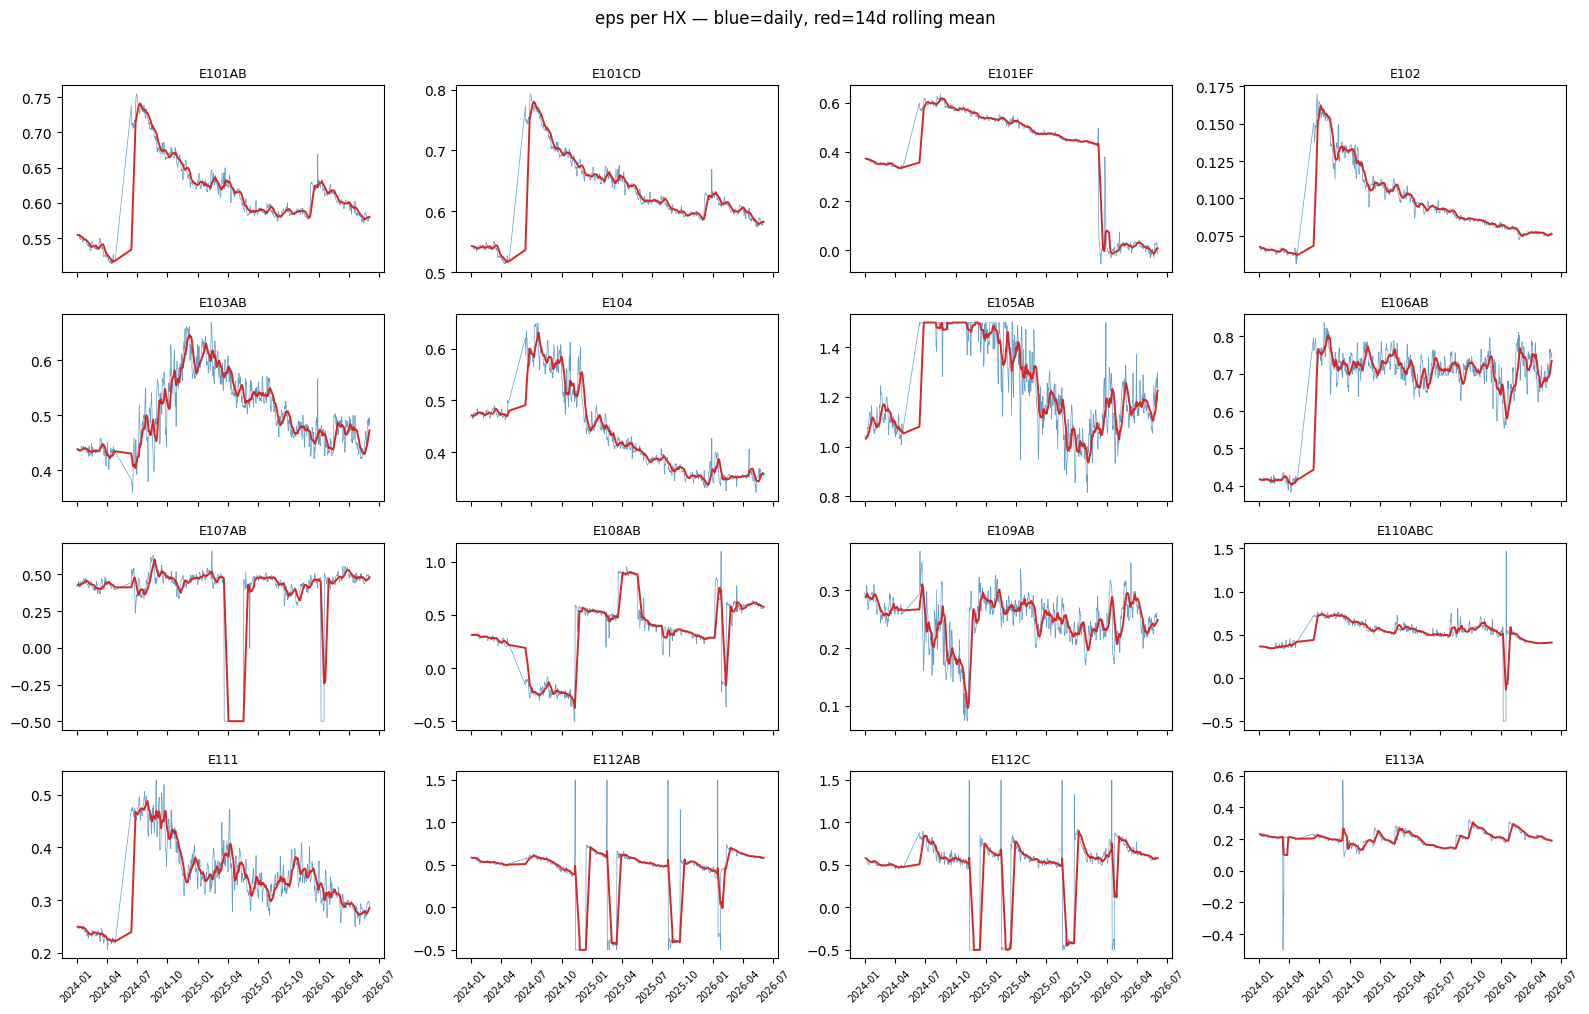

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(16, 10), sharex=True)
axes = axes.flatten()
for i, hx in enumerate(HX_CONFIG.keys()):
    col = f'{hx}_eps'
    ax = axes[i]
    if col in feat.columns:
        ax.plot(feat.index, feat[col], lw=0.5, color='tab:blue', alpha=0.7)
        ax.plot(feat.index, feat[col].rolling(14, min_periods=5).mean(), lw=1.4, color='tab:red')
    ax.set_title(hx, fontsize=9)
    ax.tick_params(axis='x', labelrotation=45, labelsize=7)
for j in range(len(HX_CONFIG), len(axes)):
    axes[j].set_visible(False)
fig.suptitle('eps per HX — blue=daily, red=14d rolling mean', y=1.01)
plt.tight_layout(); plt.show()

## 3. Date gaps (TAM segments inherited from cleaning step)

In [9]:
diffs = df.index.to_series().diff().dt.days
gaps = diffs[diffs > 1]
print(f'{len(gaps)} gap(s) > 1 day in the cleaned-CSV index:')
gaps

1 gap(s) > 1 day in the cleaned-CSV index:


Timestamp
2024-06-14    49.0
Name: Timestamp, dtype: float64